In [1]:
# CTC SCAAML data cleaned-up experiments

# In this version of the experiments, we downsample the traces to 5000 points
# This makes learning a bit easier than in the report, and seems to allow us to directly
# train the U-Net without pre-segmenting the traces in any way.

# In the next script, we will then load the U-Net and evaluate it on various versions of the test data
# as well as in cross-implementation and corruption experiments.

# Enable auto-reloading of modules
%load_ext autoreload
%autoreload 2


In [ ]:
import model_library as ml
import learning_rates as lr

from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.models import model_from_json

from keras import backend as K

from matplotlib import pyplot as plt

from experiments import train_unet_ctc

2025-04-16 16:55:02.909944: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-16 16:55:02.966072: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-16 16:55:03.352947: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/cuda-11.8/lib64:/usr/local/cuda-11.8/lib64
2025-04-16 16:55:03.352980: W tensorflow/com

In [ ]:
import numpy as np
from processing import resize_data

# TODO: The CM1 dataset is not included in this repository.
# You must obtain the CM1 data yourself, downsample it to the target size
# using processing.resize_data, and update the path below accordingly.
CM1_DATA_DIR = '../data/cm1'  # <-- update this path to point to your CM1 data

# Load the CM1 data
data = np.load(f'{CM1_DATA_DIR}/Test_all_50000.npz')
data2 = np.load(f'{CM1_DATA_DIR}/H_first5648_50000.npz')

# Extract X and Y from the data
X, Y = data['X'], data['Y']
Xh, Yh = data2['X'], data2['Y']

# Downsample each trace to 1000 points
X_downsampled = resize_data(X, 1000)
Xh_downsampled = resize_data(Xh, 1000)

print(f"Original shape: {X.shape} -> Downsampled shape: {X_downsampled.shape}")
print(f"Original hold shape: {Xh.shape} -> Downsampled hold shape: {Xh_downsampled.shape}")

100%|██████████| 5648/5648 [00:01<00:00, 5372.01it/s]

Original shape: (2048, 50000) -> Downsampled shape: (2048, 1000)
Original hold shape: (5648, 50000) -> Downsampled hold shape: (5648, 1000)


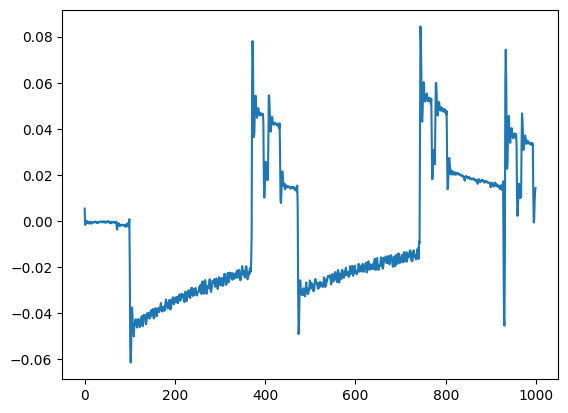

In [4]:
plt.plot(Xh_downsampled[0])

In [5]:
# resample both to 2000 points to get more space
X_downsampled2 = resize_data(X, 2000)
Xh_downsampled2 = resize_data(Xh, 2000)

X_downsampled5 = resize_data(X, 5000)
Xh_downsampled5 = resize_data(Xh, 5000)


100%|██████████| 5648/5648 [00:01<00:00, 4740.08it/s]


In [6]:
check = ModelCheckpoint('unet_full_cm1_5000_101.keras', save_best_only=True, save_weights_only=True)

2025-04-16 16:55:15.524229: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-04-16 16:55:15.538978: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-04-16 16:55:15.539067: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-04-16 16:55:15.539381: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuil

Epoch 1/101
Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


2025-04-16 16:55:39.418004: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:428] Loaded cuDNN version 8904
2025-04-16 16:55:40.630431: I tensorflow/compiler/xla/service/service.cc:173] XLA service 0x566741fa9000 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-04-16 16:55:40.630445: I tensorflow/compiler/xla/service/service.cc:181]   StreamExecutor device (0): NVIDIA GeForce RTX 4070, Compute Capability 8.9
2025-04-16 16:55:40.632983: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-16 16:55:40.705164: I tensorflow/compiler/jit/xla_compilation_cache.cc:477] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


159/159 [==============================] - 190s 1s/step - loss: 734.0792 - val_loss: 1171.3132 - lr: 1.0000e-05
Epoch 2/101
159/159 [==============================] - 157s 989ms/step - loss: 374.2173 - val_loss: 1711.0089 - lr: 1.0900e-04
Epoch 3/101
159/159 [==============================] - 156s 979ms/step - loss: 363.0362 - val_loss: 567.6230 - lr: 2.0800e-04
Epoch 4/101
159/159 [==============================] - 154s 971ms/step - loss: 361.6263 - val_loss: 390.2992 - lr: 3.0700e-04
Epoch 5/101
159/159 [==============================] - 153s 966ms/step - loss: 361.2821 - val_loss: 389.8084 - lr: 4.0600e-04
Epoch 6/101
159/159 [==============================] - 155s 978ms/step - loss: 361.0001 - val_loss: 374.6148 - lr: 5.0500e-04
Epoch 7/101
159/159 [==============================] - 156s 979ms/step - loss: 360.7902 - val_loss: 368.1387 - lr: 6.0400e-04
Epoch 8/101
159/159 [==============================] - 155s 976ms/step - loss: 360.6275 - val_loss: 380.7655 - lr: 7.0300e-04
Epoch

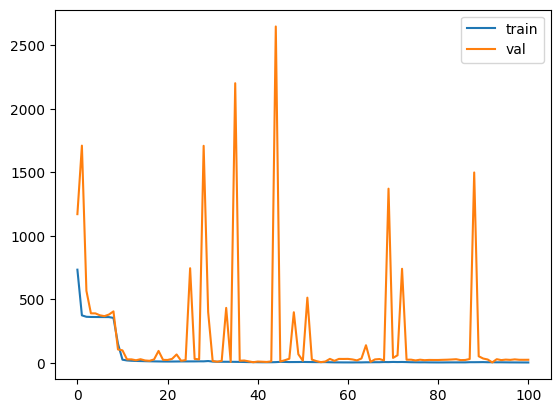

In [7]:
unet5, history = train_unet_ctc(Xh_downsampled5, Yh, epochs=101, seq_length=5000, num_features=512, batch_size=32, check=check)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','val'])


64/64 [==============================] - 4s 49ms/step
Mean fuzz ratio: 99.83
Std dev fuzz ratio: 0.39
Min fuzz ratio: 97.00
Max fuzz ratio: 100.00


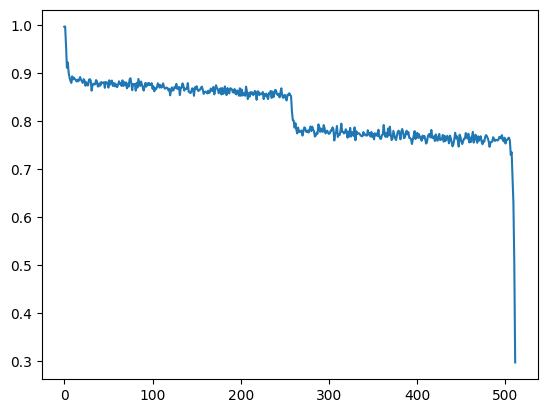

In [10]:
# Evaluate the model on the test data
# Get actual sequence length from input shape
seq_length = X_downsampled5.shape[1]  # Should be 2000
num_features = Y.shape[1]  # Number of features in Y

# Predict and decode with correct sequence length
Z_test = unet5.predict(X_downsampled5, batch_size=32)
Z_test_decoded = K.ctc_decode(Z_test, 
                             input_length=np.ones(Z_test.shape[0]) * seq_length,  # Use 2000 instead of 1000
                             greedy=True)[0][0].numpy()
Z_test_decoded = Z_test_decoded[:, 0:num_features]
acc_test = np.mean(Z_test_decoded == Y, axis=0)
plt.plot(acc_test)

from fuzzywuzzy import fuzz

def binary_array_to_string(arr):
    return ''.join(map(str, arr.astype(int)))

# Calculate Levenshtein distances for each sample
distances = []
for i in range(len(Z_test_decoded)):
    pred_str = binary_array_to_string(Z_test_decoded[i])
    true_str = binary_array_to_string(Y[i])
    distance = fuzz.ratio(pred_str, true_str)
    distances.append(distance)

distances = np.array(distances)

print(f"Mean fuzz ratio: {np.mean(distances):.2f}")
print(f"Std dev fuzz ratio: {np.std(distances):.2f}")
print(f"Min fuzz ratio: {np.min(distances):.2f}")
print(f"Max fuzz ratio: {np.max(distances):.2f}")


In [ ]:
unet5.summary()
unet5.save('../data/pretrained/unet_5000_101.keras')
unet5.save_weights('../data/pretrained/unet_5000_101_weights.keras')
unet5_structure_json = unet5.to_json()
with open('../data/pretrained/unet_5000_101_structure.json', 'w') as f:
    f.write(unet5_structure_json)


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 5000, 1)]    0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 5000, 64)     256         ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 5000, 64)    256         ['conv1d[0][0]']                 
 alization)                                                                                       
                                                                                                  
 dropout (Dropout)              (None, 5000, 64)     0           ['batch_normalization[0][0]']

 conv1d_12 (Conv1D)             (None, 1250, 256)    590080      ['concatenate_1[0][0]']          
                                                                                                  
 batch_normalization_12 (BatchN  (None, 1250, 256)   1024        ['conv1d_12[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 conv1d_13 (Conv1D)             (None, 1250, 256)    196864      ['batch_normalization_12[0][0]'] 
                                                                                                  
 batch_normalization_13 (BatchN  (None, 1250, 256)   1024        ['conv1d_13[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 up_sampli

Text(0.5, 1.0, 'CTC Probabilities vs Power Trace')

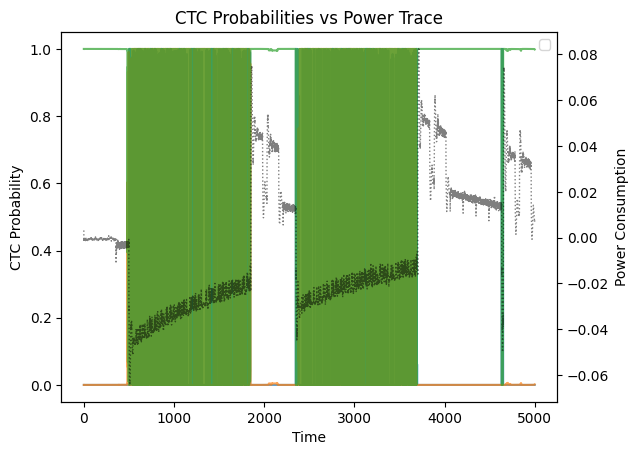

In [14]:
# Create figure and axis
fig, ax1 = plt.subplots()

# Plot CTC probabilities on first y-axis
ax1.plot(Z_test[0], alpha=0.7)
ax1.set_ylabel('CTC Probability')
ax1.set_xlabel('Time')

# Create second y-axis and plot power trace
ax2 = ax1.twinx()
ax2.plot(X_downsampled5[0], 'k:', alpha=0.5, linewidth=1)
ax2.set_ylabel('Power Consumption')

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, ['0', '1', 'blank', 'Power Trace'], loc='upper right')

plt.title('CTC Probabilities vs Power Trace')